In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Read & Examine the data

In [32]:
data = pd.read_csv('claimants.csv')
data.shape

(1340, 7)

In [34]:
data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   ATTORNEY  1340 non-null   int64  
 2   CLMSEX    1328 non-null   float64
 3   CLMINSUR  1299 non-null   float64
 4   SEATBELT  1292 non-null   float64
 5   CLMAGE    1151 non-null   float64
 6   LOSS      1340 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


##### Handle Null values

In [39]:
data.dropna(inplace=True)

In [41]:
data.drop('CASENUM', axis = 1, inplace=True)

In [43]:
data.head(3)

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330


##### Split the data

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X = data.iloc[:,1:]
y = data.iloc[:,0]

In [49]:
X.head(3)

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330


In [52]:
y.head(3)

0    0
1    1
2    1
Name: ATTORNEY, dtype: int64

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((876, 5), (220, 5), (876,), (220,))

##### Build & evaluate the model

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [59]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [61]:
yhat_train = model.predict(X_train)

              precision    recall  f1-score   support

           0       0.78      0.65      0.71       467
           1       0.66      0.79      0.72       409

    accuracy                           0.71       876
   macro avg       0.72      0.72      0.71       876
weighted avg       0.72      0.71      0.71       876



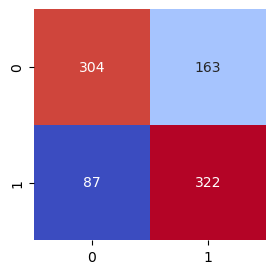

In [63]:
plt.figure(figsize=(3,3))
cm = confusion_matrix(y_train,yhat_train)
sns.heatmap(cm, cmap='coolwarm', annot=True, fmt='d', cbar=False)
print(classification_report(y_train,yhat_train))
plt.show()

In [65]:
def plot_roc(y,yhat):
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y_train, yhat_train)
    auc
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

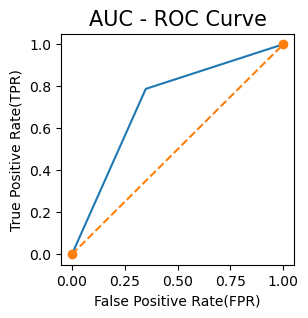

In [67]:
plot_roc(y_train,yhat_train)

In [69]:
yhat_test = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.68      0.69      0.68       111
           1       0.68      0.66      0.67       109

    accuracy                           0.68       220
   macro avg       0.68      0.68      0.68       220
weighted avg       0.68      0.68      0.68       220



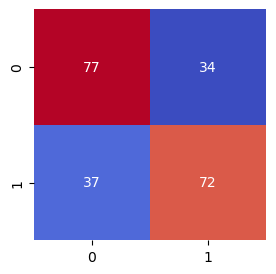

In [71]:
plt.figure(figsize=(3,3))
cm = confusion_matrix(y_test,yhat_test)
sns.heatmap(cm, cmap='coolwarm', annot=True, fmt='d', cbar=False)
print(classification_report(y_test,yhat_test))
plt.show()

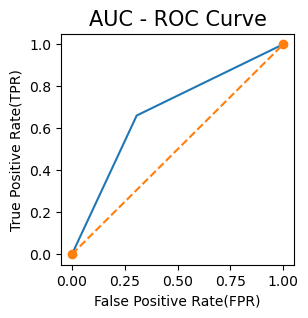

In [73]:
plot_roc(y_test,yhat_test)

In [75]:
# Predicts the class
model.predict(X_test)

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1],
      dtype=int64)

In [77]:
# Predicts the probability
proba = model.predict_proba(X_test)

In [79]:
#### Probability of 1
model.predict_proba(X_test)[:,1]

array([5.89654100e-01, 6.14424281e-01, 5.99136580e-09, 7.05969929e-01,
       1.41351864e-01, 6.91759108e-01, 7.08009124e-01, 6.00872262e-01,
       6.21220155e-01, 5.31789793e-01, 5.14048421e-01, 7.54986852e-01,
       4.55573009e-01, 3.10990079e-01, 7.14809259e-01, 5.68899235e-01,
       1.11616371e-01, 3.48440140e-01, 1.79402502e-01, 3.55454266e-02,
       4.87290658e-01, 6.67454942e-01, 6.29224924e-01, 5.78551806e-01,
       2.19937594e-01, 1.41638898e-01, 2.52330771e-01, 2.30565785e-08,
       2.92773783e-01, 6.78197086e-01, 2.90443903e-01, 2.48919948e-01,
       2.03210362e-01, 6.15134698e-01, 5.48690104e-01, 1.29572553e-01,
       2.74896211e-01, 5.67057499e-01, 6.18969631e-01, 6.69531617e-01,
       7.07011597e-01, 7.06070196e-01, 2.00346314e-01, 8.93172929e-02,
       6.70826920e-01, 6.20512247e-01, 3.31336270e-10, 6.39189777e-01,
       6.82384597e-01, 3.47715608e-01, 5.62580591e-01, 3.25734686e-01,
       5.32966216e-01, 6.77626113e-01, 3.19264133e-01, 1.22599808e-13,
      

In [81]:
def set_threshold(X,y,threshold):
    prob_1 = model.predict_proba(X)[:,1]
    pdf = pd.DataFrame(prob_1, columns=['probability'])
    yhat = pdf['probability'].apply(lambda x: 1 if x>threshold else 0)

    TN, FP, FN, TP = confusion_matrix(y, yhat).ravel()    
    return  {'Threshold':threshold,
                               'Correct_Predictions':TP+TN,
                               'TP':TP,
                               'TN':TN,
                               'FP':FP,
                               'FN':FN,
                               'Precision':TP/(TP+FP),
                               'Recall':TP/(TP+FN),
                                'Accuracy':(TP+TN)/(TP+TN+FP+FN)
            }

In [83]:
set_threshold(X_train,y_train,0.6)

{'Threshold': 0.6,
 'Correct_Predictions': 616,
 'TP': 249,
 'TN': 367,
 'FP': 100,
 'FN': 160,
 'Precision': 0.7134670487106017,
 'Recall': 0.60880195599022,
 'Accuracy': 0.7031963470319634}

In [85]:
def all_thresholds(X,y):
    pred_threshold = pd.DataFrame( columns = ['Threshold',
                               'Correct_Predictions',
                                              'TP',
                                              'TN',
                               'FP',
                               'FN',
                               'Precision',
                               'Recall',
                                'Accuracy'],index=None) 

    for i in range(1,11):
        threshold = i/10
        vals = set_threshold(X,y,threshold)
        df = pd.DataFrame(vals, index=[0])
        pred_threshold = pd.concat([pred_threshold,df], ignore_index=True)
    return pred_threshold

In [87]:
all_thresholds(X_train,y_train)

C:\Users\Pandhari\AppData\Local\Temp\ipykernel_22524\2908865487.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pred_threshold = pd.concat([pred_threshold,df], ignore_index=True)
C:\Users\Pandhari\AppData\Local\Temp\ipykernel_22524\1834948361.py:13: RuntimeWarning: invalid value encountered in scalar divide
  'Precision':TP/(TP+FP),
C:\Users\Pandhari\AppData\Local\Temp\ipykernel_22524\1834948361.py:13: RuntimeWarning: invalid value encountered in scalar divide
  'Precision':TP/(TP+FP),
C:\Users\Pandhari\AppData\Local\Temp\ipykernel_22524\1834948361.py:13: RuntimeWarning: invalid value encountered in scalar divide
  'Precision':TP/(TP+FP),


,Threshold,Correct_Predictions,TP,TN,FP,FN,Precision,Recall,Accuracy
0,0.1,472,401,71,396,8,0.503137,0.980440,0.538813
1,0.2,515,390,125,342,19,0.532787,0.953545,0.587900
2,0.3,564,371,193,274,38,0.575194,0.907090,0.643836
3,0.4,611,343,268,199,66,0.632841,0.838631,0.697489
4,0.5,626,322,304,163,87,0.663918,0.787286,0.714612
5,0.6,616,249,367,100,160,0.713467,0.608802,0.703196
6,0.7,535,96,439,28,313,0.774194,0.234719,0.610731
7,0.8,467,0,467,0,409,NaN,0.000000,0.533105
8,0.9,467,0,467,0,409,NaN,0.000000,0.533105
9,1.0,467,0,467,0,409,NaN,0.000000,0.533105
